# BÀI THỰC HÀNH 03. SPATIAL/FREQUENCY DOMAIN - FILTERs & THEIR APPLICATIONS
Trong bài thực hành này, chúng ta sẽ áp dụng các bộ lọc trong miền không gian và miền tần số cho các bài toán: giảm nhiễu (denoising), làm sắc nét ảnh (sharpening), và phát hiện biên (edge detection).


## 0. Cài đặt Môi trường & Các hàm Tiện ích
Import các thư viện cần thiết và thiết lập hàm hiển thị chung.


In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Hàm tiện ích để đọc ảnh xám
def read_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Không thể đọc ảnh: {path}")
    return img

# Hàm hiển thị ảnh
def show_gray(title, img):
    plt.figure(figsize=(5,4))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Hiển thị nhiều ảnh trên 1 dòng
def show_multiple(titles, images, cols=3):
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=(cols*4, rows*4))
    for i, (title, img) in enumerate(zip(titles, images)):
        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


## 1. Biến đổi Fourier & Lọc miền Tần số (Frequency Domain)
Ở phần này, ta sử dụng lý thuyết miền tần số để phân tách các thành phần tần số thấp (khu vực trơn) và định hướng tần số cao (chi tiết, cạnh). 
Áp dụng High-pass filter (HPF) và Low-pass filter (LPF) lên ảnh `freq_domain_eg1.png` và `freq_domain_eg2.png`.


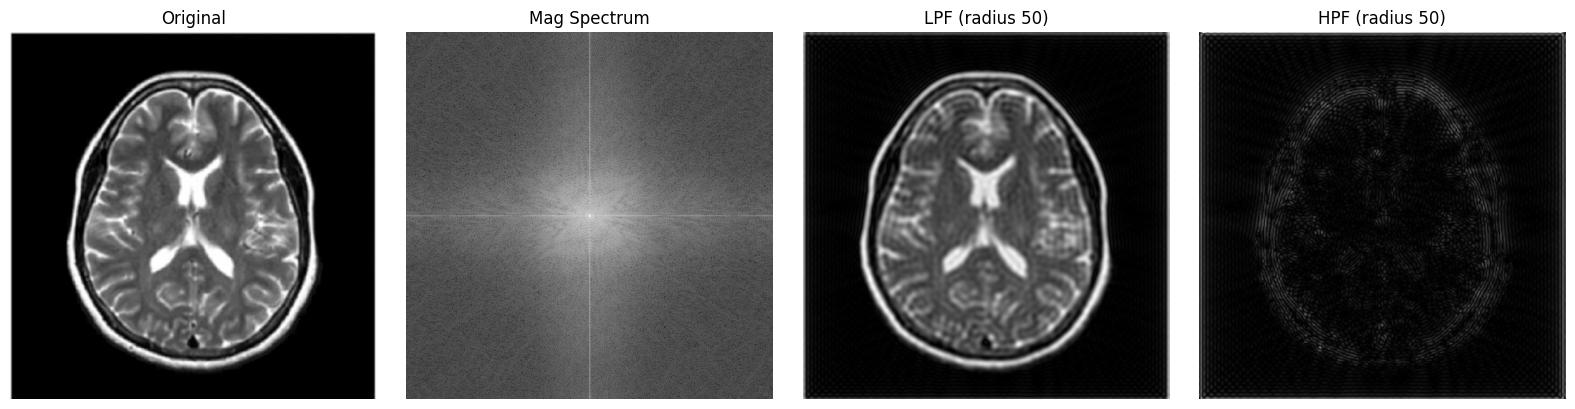

In [4]:
# Helper functions for frequency operations
def get_magnitude_spectrum(img):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    mag_spectrum = np.log1p(np.abs(fshift))
    return f, fshift, mag_spectrum

def circular_mask(shape, radius, is_lpf=True):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    # create grid
    Y, X = np.ogrid[:rows, :cols]
    dist_sq = (X - ccol)**2 + (Y - crow)**2
    mask = dist_sq <= radius**2
    if not is_lpf:
        mask = ~mask
    return mask.astype(np.float64)

def apply_freq_filter(fshift, mask):
    fshift_filtered = fshift * mask
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    return np.abs(img_back)

# Test với ảnh tần số
img_freq = read_gray('../Resources/freq_domain_eg1.png')
if img_freq is not None:
    _, fshift, mag = get_magnitude_spectrum(img_freq)
    
    # LPF (Low-pass)
    mask_lpf = circular_mask(img_freq.shape, radius=50, is_lpf=True)
    img_lpf = apply_freq_filter(fshift, mask_lpf)
    
    # HPF (High-pass)
    mask_hpf = circular_mask(img_freq.shape, radius=50, is_lpf=False)
    img_hpf = apply_freq_filter(fshift, mask_hpf)
    
    show_multiple(['Original', 'Mag Spectrum', 'LPF (radius 50)', 'HPF (radius 50)'],
                  [img_freq, mag, img_lpf, img_hpf], cols=4)


## 2. Giảm nhiễu Hình ảnh (Denoising Pipelines)
Sử dụng các bộ lọc như Mean, Gaussian, Median để loại bỏ các loại nhiễu khác nhau: Gaussian noise, Pepper/Salt, và Poisson noise.
Phân tích xem loại nhiễu nào phù hợp với bộ lọc nào.


-> Với nhiễu Gaussian: Bộ lọc Gaussian/Mean cho kết quả mịn, bảo toàn tổng lượng sáng của pixel tốt hơn.


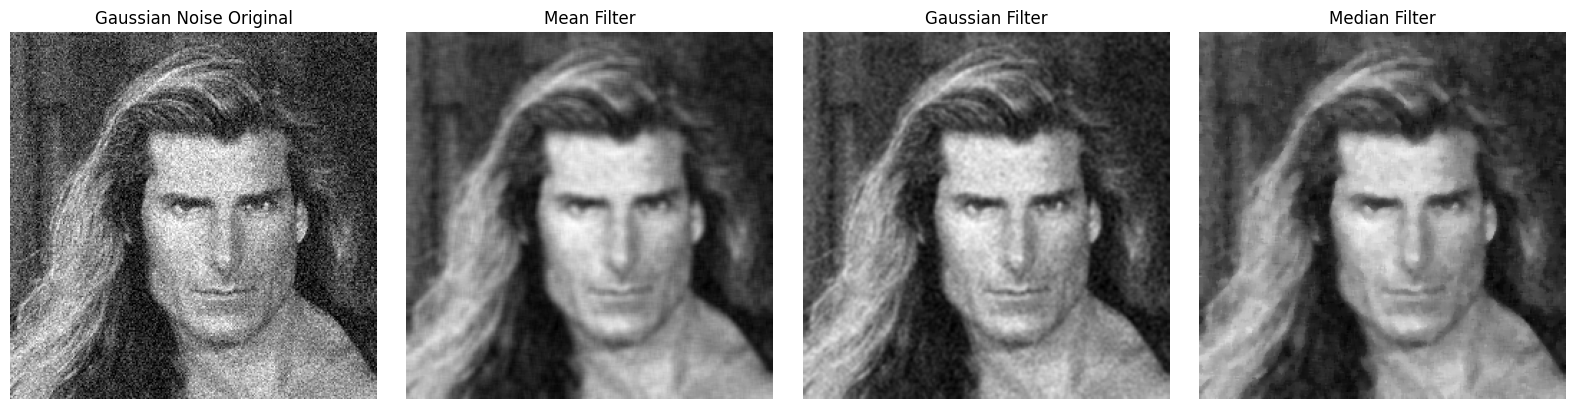

-> Với nhiễu Pepper (Impulse noise): Bộ lọc Median khử hoàn toàn các điểm đột biến mà không làm mờ nhiều viền.


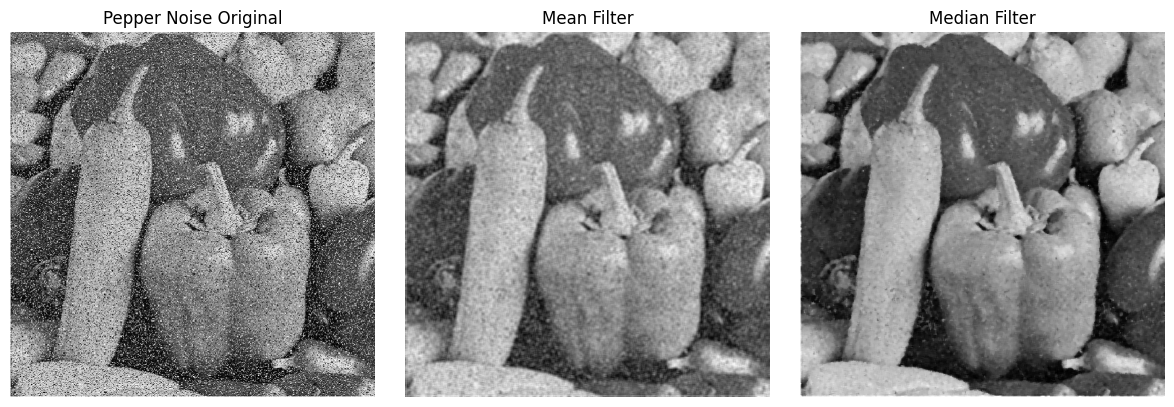

-> Với nhiễu Poisson: Phụ thuộc vào ảnh, có thể dùng Gaussian hoặc kết hợp với thuật toán nâng cao hơn (Non-local means).


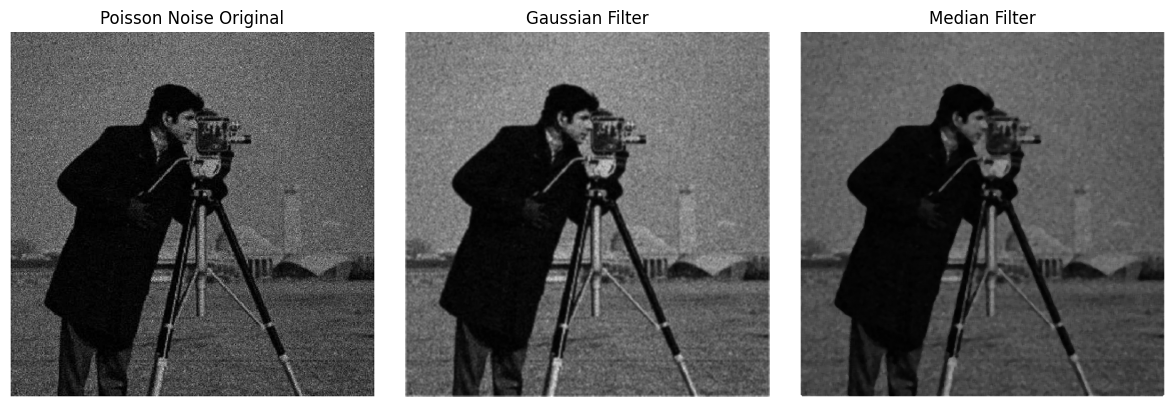

In [5]:
img_gauss = read_gray('../Resources/gaussian_noise_example_1.png')
img_peper = read_gray('../Resources/peper_noise_example_1.png')
img_poison = read_gray('../Resources/poison_noise_example_1.png')

# 2.1 Sử dụng bộ lọc với nhiễu Gaussian
# Nhiễu Gaussian phân bố đều, ta nên dùng Mean hoặc Gaussian filter để làm mờ nó
if img_gauss is not None:
    res_gauss_mean = cv2.blur(img_gauss, (5,5))
    res_gauss_gaussian = cv2.GaussianBlur(img_gauss, (5,5), 1.0)
    res_gauss_median = cv2.medianBlur(img_gauss, 5)
    print("-> Với nhiễu Gaussian: Bộ lọc Gaussian/Mean cho kết quả mịn, bảo toàn tổng lượng sáng của pixel tốt hơn.")
    show_multiple(['Gaussian Noise Original', 'Mean Filter', 'Gaussian Filter', 'Median Filter'],
                  [img_gauss, res_gauss_mean, res_gauss_gaussian, res_gauss_median], cols=4)

# 2.2 Sử dụng bộ lọc với nhiễu Pepper (mảnh nhỏ như muối tiêu)
# Nhiễu này tạo các điểm đột biến, dùng Median filter cực kì hiệu quả
if img_peper is not None:
    res_peper_mean = cv2.blur(img_peper, (5,5))
    res_peper_median = cv2.medianBlur(img_peper, 5)
    print("-> Với nhiễu Pepper (Impulse noise): Bộ lọc Median khử hoàn toàn các điểm đột biến mà không làm mờ nhiều viền.")
    show_multiple(['Pepper Noise Original', 'Mean Filter', 'Median Filter'],
                  [img_peper, res_peper_mean, res_peper_median], cols=3)

# 2.3 Sử dụng bộ lọc với nhiễu Poisson
if img_poison is not None:
    res_poison_gauss = cv2.GaussianBlur(img_poison, (5,5), 1.0)
    res_poison_median = cv2.medianBlur(img_poison, 5)
    print("-> Với nhiễu Poisson: Phụ thuộc vào ảnh, có thể dùng Gaussian hoặc kết hợp với thuật toán nâng cao hơn (Non-local means).")
    show_multiple(['Poisson Noise Original', 'Gaussian Filter', 'Median Filter'],
                  [img_poison, res_poison_gauss, res_poison_median], cols=3)


## 3. Làm nét ảnh (Sharpening)
Làm nét ảnh bị mờ. Ta sẽ thực hiện thông qua toán tử đạo hàm bậc 2 Laplacian và phương pháp Unsharp Masking.


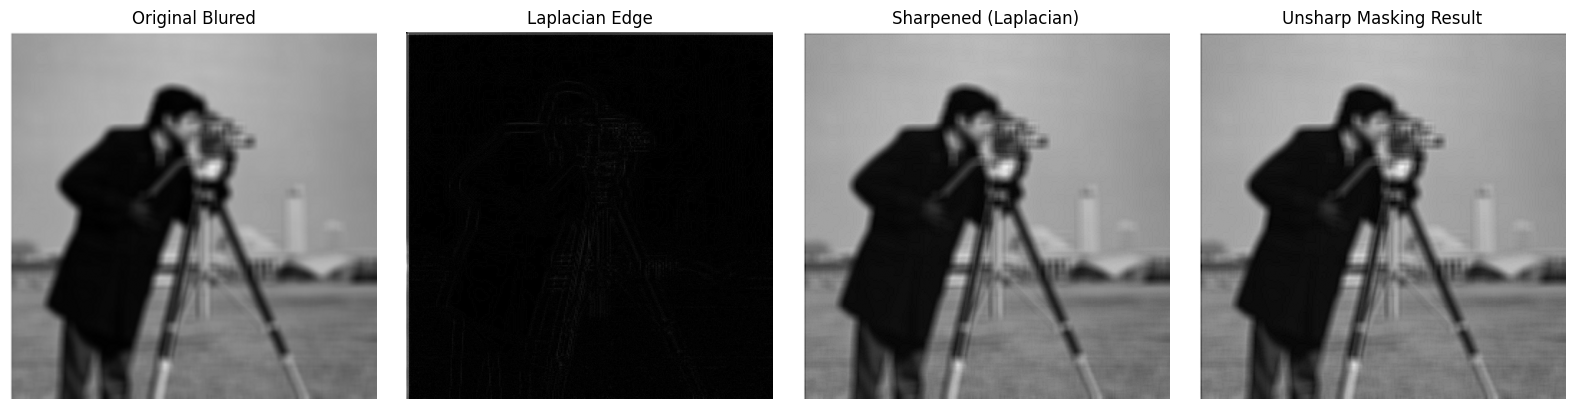

In [6]:
img_blur = read_gray('../Resources/blured_example_1.png')

if img_blur is not None:
    # 3.1 Laplacian Sharpening
    laplacian = cv2.Laplacian(img_blur, cv2.CV_64F)
    # Ảnh sắc nét = Ảnh gốc - c*Laplacian (do mask có -4 ở giữa)
    sharp_laplacian = np.clip(img_blur.astype(np.float64) - 0.7 * laplacian, 0, 255).astype(np.uint8)
    
    # 3.2 Unsharp Masking
    # Lấy high frequency = Ảnh gốc - Ảnh làm mờ
    blur_for_unsharp = cv2.GaussianBlur(img_blur, (5,5), 2.0)
    high_freq_mask = img_blur.astype(np.float64) - blur_for_unsharp.astype(np.float64)
    # Unsharp = Gốc + k * high_freq_mask
    sharp_unsharp = np.clip(img_blur.astype(np.float64) + 1.5 * high_freq_mask, 0, 255).astype(np.uint8)
    
    show_multiple(['Original Blured', 'Laplacian Edge', 'Sharpened (Laplacian)', 'Unsharp Masking Result'],
                  [img_blur, np.abs(laplacian), sharp_laplacian, sharp_unsharp], cols=4)


## 4. Trích xuất đặc trưng Cạnh (Edge Detection)
So sánh Sobel (Sobel gradient + magnitude thresholding) và thuật toán Canny.
Canny bao gồm: Gaussian Smoothing -> Sobel Gradients -> Non-maximum Suppression -> Double Threshold -> Hysteresis.


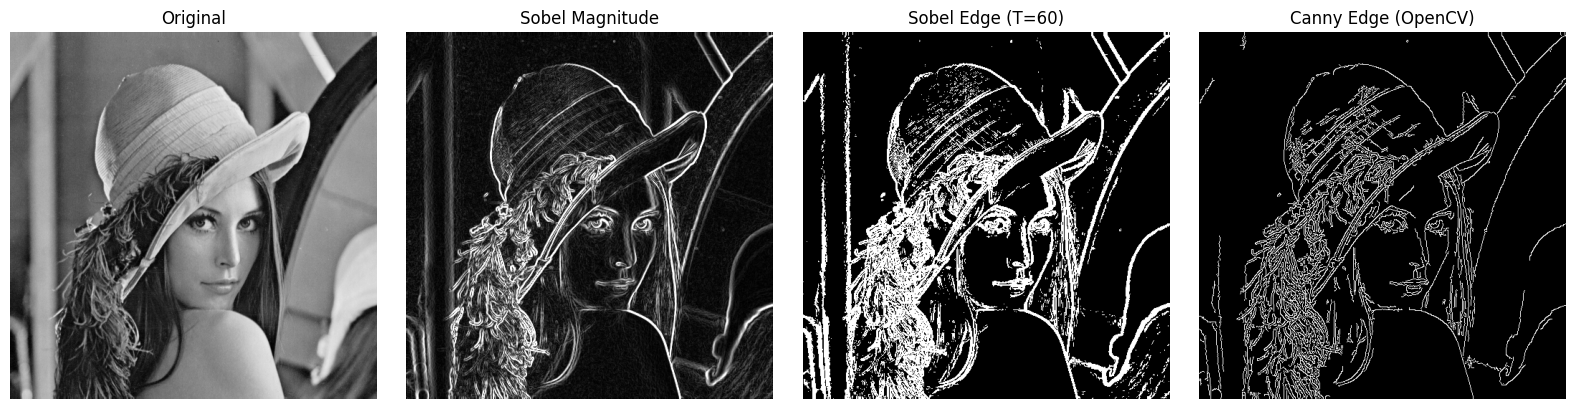

In [7]:
img_lena = read_gray('../Resources/lena.png')

if img_lena is not None:
    # 4.1 Sobel Edge
    sobel_x = cv2.Sobel(img_lena, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img_lena, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
    sobel_mag = np.clip(sobel_mag, 0, 255).astype(np.uint8)
    
    # Thresholding Sobel Map
    T = 60
    sobel_edge = (sobel_mag >= T).astype(np.uint8) * 255
    
    # 4.2 Canny Edge (Sử dụng hàm của OpenCV với threshold tính toán)
    canny_edge = cv2.Canny(img_lena, 50, 150)
    
    show_multiple(['Original', 'Sobel Magnitude', f'Sobel Edge (T={T})', 'Canny Edge (OpenCV)'],
                  [img_lena, sobel_mag, sobel_edge, canny_edge], cols=4)


## 5. Mini Project (Tích hợp: Denoise -> Sharpen -> Detect Edges)
Thử nghiệm 1 pipeline đơn giản:
1. Đọc ảnh và "cố tình" thêm nhiễu (Gaussian).
2. Chạy Denoise để giảm nhiễu (Gaussian).
3. Làm nét lại cấu trúc (Unsharp Masking).
4. Tìm cạnh (Canny).


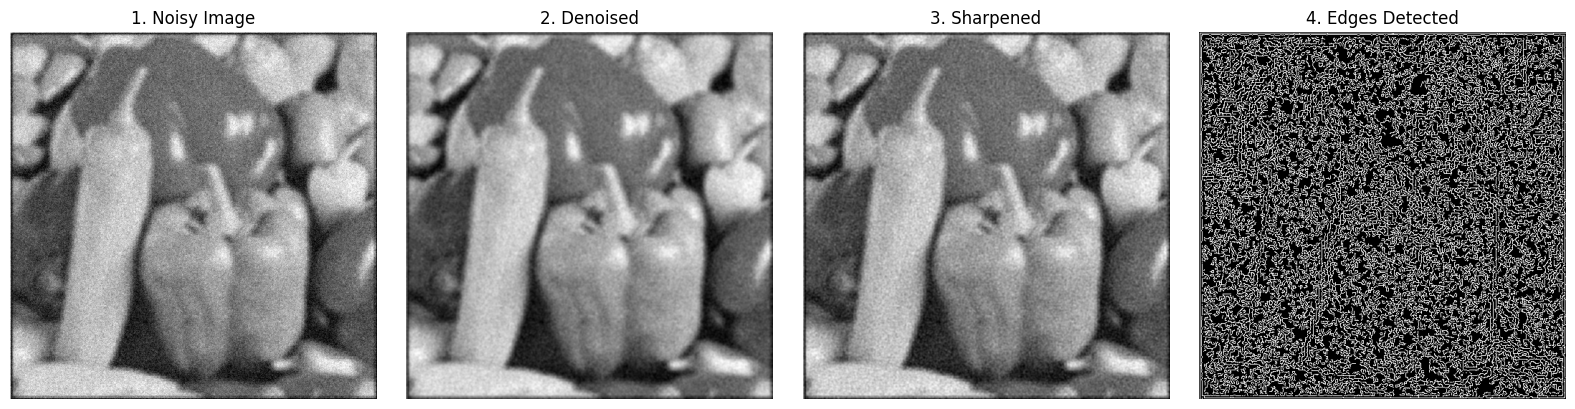

In [9]:
def add_gaussian_noise(image, sigma=20):
    noise = np.random.normal(0, sigma, image.shape)
    noisy = image.astype(np.float64) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

img_project = read_gray('../Resources/blured_example_2.png')

if img_project is not None:
    # Step 1: Add noise
    noisy_img = add_gaussian_noise(img_project, sigma=15)
    
    # Step 2: Denoise (Gaussian)
    denoised_img = cv2.GaussianBlur(noisy_img, (5,5), 1.0)
    
    # Step 3: Sharpen (Unsharp Masking)
    blur_stage = cv2.GaussianBlur(denoised_img, (5,5), 2.0)
    mask = denoised_img.astype(np.float64) - blur_stage.astype(np.float64)
    sharpened_img = np.clip(denoised_img.astype(np.float64) + 1.2 * mask, 0, 255).astype(np.uint8)
    
    # Step 4: Edge Detection (Canny)
    edges = cv2.Canny(sharpened_img, 60, 120)
    
    show_multiple(['1. Noisy Image', '2. Denoised', '3. Sharpened', '4. Edges Detected'],
                  [noisy_img, denoised_img, sharpened_img, edges], cols=4)
